In [ ]:
# Get Stim Channels

import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt


In [ ]:
# Configuration

file_path = '/mnt/movement/users/jaizor/xtra/Ξ/HD_Bel/demo_subject_1.mff'
subject_id = "demo_subject_1"

In [3]:
# Helper Functions


def find_stim_events_single_subject(
    raw: mne.io.Raw,
    threshold: float = 0.5,
    include_subject_col: bool = False,
    subject_id: str = None
) -> pd.DataFrame:
    """
    Extract stim events from a single subject's Raw EEG data by binarizing analog channels.
    """
    # --- Find stim channels ---
    stim_candidates = []
    for ch_name, ch_type in zip(raw.ch_names, raw.get_channel_types()):
        if ch_type in ['stim', 'misc']:
            stim_candidates.append(ch_name)
        elif any(kw in ch_name.upper() for kw in ['STI', 'TRIG', 'TTL']):
            stim_candidates.append(ch_name)
        elif ch_name[0].isdigit() and len(ch_name) <= 3:
            stim_candidates.append(ch_name)
    stim_channels = sorted(set(stim_candidates))
    
    # --- Extract events ---
    events = []
    sfreq = raw.info['sfreq']
    for ch in stim_channels:
        if ch not in raw.ch_names:
            continue
        data = raw.get_data(picks=[ch])[0]
        digital = (data > threshold).astype(int)
        diff = np.diff(digital, prepend=0)
        onset_samples = np.where(diff == 1)[0]
        onset_times = onset_samples / sfreq
        for t, s in zip(onset_times, onset_samples):
            row = {
                'channel': ch,
                'time_sec': t,
                'sample': int(s),
                'sfreq': sfreq
            }
            events.append(row)
    
    df = pd.DataFrame(events) if events else pd.DataFrame(
        columns=['channel', 'time_sec', 'sample', 'sfreq']
    )
    
    if include_subject_col:
        if subject_id is None:
            raise ValueError("subject_id must be provided if include_subject_col=True")
        df['subject'] = subject_id
    
    return df.sort_values('time_sec').reset_index(drop=True)

def plot_stim_events_single(
    events_df: pd.DataFrame,
    subject_id: str = None,
    figsize: tuple = (12, 4)
):
    """
    Plot stim events over time for a single subject.
    """
    if events_df.empty:
        print("⚠️ No events to plot.")
        return
    
    if subject_id is not None and 'subject' in events_df.columns:
        df = events_df[events_df['subject'] == subject_id].copy()
    else:
        df = events_df.copy()
    
    if df.empty:
        print(f"⚠️ No events found for subject {subject_id}")
        return
    
    plt.figure(figsize=figsize)
    for ch in df['channel'].unique():
        ch_events = df[df['channel'] == ch]
        plt.scatter(ch_events['time_sec'], [ch] * len(ch_events), label=ch, alpha=0.7)
    
    title = f"Stim Events for {subject_id}" if subject_id else "Stim Events"
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Channel")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [4]:
print(f"Loading MFF file: {file_path}...")
raw = mne.io.read_raw_egi(file_path, preload=True, events_as_annotations=True)

Loading MFF file: /mnt/movement/users/jaizor/xtra/Ξ/HD_Bel/demo_subject_1.mff...
Reading EGI MFF Header from /mnt/movement/users/jaizor/xtra/Ξ/HD_Bel/demo_subject_1.mff...
    Reading events ...
    Assembling measurement info ...
    Excluding events {} ...
Reading 0 ... 129970  =      0.000 ...   259.940 secs...


In [5]:
# --- Part A: High-Level Annotation Processing ---
print("\n--- Part A: Annotation-Based Event Extraction ---")
print("Original Annotations:")
print(raw.annotations)


--- Part A: Annotation-Based Event Extraction ---
Original Annotations:
<Annotations | 8 segments: TT255 (4), c (1), o (1), x (2)>


In [6]:
# Mapping for experimental conditions (Verify this against your protocol)
condition_mapping = {
    'c': 'Eyes Closed',
    'o': 'Eyes Open',
    'x': 'Condition_X',
    'TT255': 'Sync_Pulse'
}


# Rename annotations for clarity
raw.annotations.rename(condition_mapping)
print("\nRenamed Annotations:")
print(raw.annotations)



Renamed Annotations:
<Annotations | 8 segments: Condition_X (2), Eyes Closed (1), Eyes Open ...>


In [7]:
# Extract specific events for analysis
events, event_id = mne.events_from_annotations(
    raw, 
    event_id={'Eyes Closed': 1, 'Eyes Open': 2}
)

print("\nFiltered Events Array (Eyes Open/Closed only):")
print(events)
print("\nEvent ID Dictionary:")
print(event_id)

Used Annotations descriptions: [np.str_('Eyes Closed'), np.str_('Eyes Open')]

Filtered Events Array (Eyes Open/Closed only):
[[ 3422     0     1]
 [67849     0     2]]

Event ID Dictionary:
{np.str_('Eyes Closed'): 1, np.str_('Eyes Open'): 2}


In [8]:
# --- Part B: Low-Level Signal Verification ---
print("\n--- Part B: Raw Channel Stimulus Detection ---")
stim_events_df = find_stim_events_single_subject(
    raw, 
    threshold=0.5, 
    include_subject_col=True, 
    subject_id=subject_id
)


--- Part B: Raw Channel Stimulus Detection ---


Detected Stimulus Events from Raw Channels:
  channel  time_sec  sample  sfreq         subject
0       c     6.844    3422  500.0  demo_subject_1
1   TT255     6.852    3426  500.0  demo_subject_1
2       x   126.850   63425  500.0  demo_subject_1
3   TT255   126.858   63429  500.0  demo_subject_1
4       o   135.698   67849  500.0  demo_subject_1


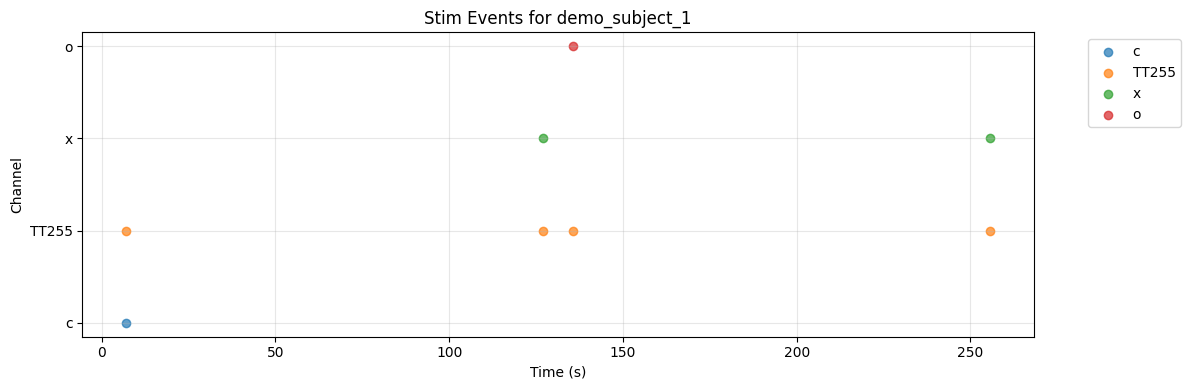

In [9]:
print("Detected Stimulus Events from Raw Channels:")
print(stim_events_df.head())

# Visualize the raw triggers
plot_stim_events_single(stim_events_df, subject_id=subject_id)

In [12]:
# --- Part C: Manual Data Extraction ---
print("\n--- Part C: Extracting Continuous Blocks Manually ---")

# 1. Define Start Times from your DataFrame
# We pick the first 'c' (Row 0) and the first 'o' (Row 4) from your table
start_time_closed = stim_events_df[stim_events_df['channel'] == 'c'].iloc[0]['time_sec']
start_time_open = stim_events_df[stim_events_df['channel'] == 'o'].iloc[0]['time_sec']

# 2. Define End Times (Start + 60 seconds)
duration = 60
end_time_closed = start_time_closed + duration
end_time_open = start_time_open + duration

print(f"Extracting Eyes Closed: {start_time_closed:.3f}s to {end_time_closed:.3f}s")
print(f"Extracting Eyes Open:   {start_time_open:.3f}s to {end_time_open:.3f}s")




--- Part C: Extracting Continuous Blocks Manually ---
Extracting Eyes Closed: 6.844s to 66.844s
Extracting Eyes Open:   135.698s to 195.698s


In [13]:
# 3. Cut and Save 'Eyes Closed' Block
raw_closed = raw.copy().crop(tmin=start_time_closed, tmax=end_time_closed)
filename_closed = f"{subject_id}_eyes_closed_manual.fif"
raw_closed.save(filename_closed, overwrite=True)
print(f"✅ Saved: {filename_closed}")

# 4. Cut and Save 'Eyes Open' Block
raw_open = raw.copy().crop(tmin=start_time_open, tmax=end_time_open)
filename_open = f"{subject_id}_eyes_open_manual.fif"
raw_open.save(filename_open, overwrite=True)
print(f"✅ Saved: {filename_open}")

Overwriting existing file.
Writing /mnt/movement/users/jaizor/xtra/Ξ/HD_Bel/demo_subject_1_eyes_closed_manual.fif
Overwriting existing file.
Closing /mnt/movement/users/jaizor/xtra/Ξ/HD_Bel/demo_subject_1_eyes_closed_manual.fif
[done]


/tmp/ipykernel_23479/1158958307.py:4: RuntimeWarning: This filename (/mnt/movement/users/jaizor/xtra/Ξ/HD_Bel/demo_subject_1_eyes_closed_manual.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_closed.save(filename_closed, overwrite=True)


✅ Saved: demo_subject_1_eyes_closed_manual.fif
Overwriting existing file.
Writing /mnt/movement/users/jaizor/xtra/Ξ/HD_Bel/demo_subject_1_eyes_open_manual.fif
Overwriting existing file.
Closing /mnt/movement/users/jaizor/xtra/Ξ/HD_Bel/demo_subject_1_eyes_open_manual.fif
[done]
✅ Saved: demo_subject_1_eyes_open_manual.fif


/tmp/ipykernel_23479/1158958307.py:10: RuntimeWarning: This filename (/mnt/movement/users/jaizor/xtra/Ξ/HD_Bel/demo_subject_1_eyes_open_manual.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_open.save(filename_open, overwrite=True)
